<a href="https://colab.research.google.com/github/ArshiyaNasirin/ArshiyaNasirin/blob/main/Randomforest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7043
Columns: 21


In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].dtype)
print("Missing values:", df['TotalCharges'].isnull().sum())

float64
Missing values: 11


In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Missing values after handling:", df['TotalCharges'].isnull().sum())

Missing values after handling: 0


In [8]:
df = df.drop('customerID', axis=1)

print("customerID removed.")
print("Remaining columns:", df.shape[1])

customerID removed.
Remaining columns: 20


In [9]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [11]:
X = pd.get_dummies(X, drop_first=True)

print("X shape after encoding:", X.shape)
print(X.head())

X shape after encoding: (7043, 30)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False         

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [14]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


In [15]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9980475683351083
Testing Accuracy: 0.7863733144073811


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409

Confusion Matrix:
[[924 111]
 [190 184]]


In [17]:
rf_model_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model_tuned.fit(X_train, y_train)

y_train_pred_tuned = rf_model_tuned.predict(X_train)
y_test_pred_tuned = rf_model_tuned.predict(X_test)

print("Tuned Random Forest trained successfully!")

Tuned Random Forest trained successfully!


In [18]:
from sklearn.metrics import accuracy_score

train_accuracy_tuned = accuracy_score(y_train, y_train_pred_tuned)
test_accuracy_tuned = accuracy_score(y_test, y_test_pred_tuned)

print("Tuned Training Accuracy:", train_accuracy_tuned)
print("Tuned Testing Accuracy:", test_accuracy_tuned)

Tuned Training Accuracy: 0.8409655662051828
Tuned Testing Accuracy: 0.8026969481902059


In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print("Tuned Classification Report:")
print(classification_report(y_test, y_test_pred_tuned))

print("Tuned Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_tuned))

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Tuned Confusion Matrix:
[[937  98]
 [180 194]]


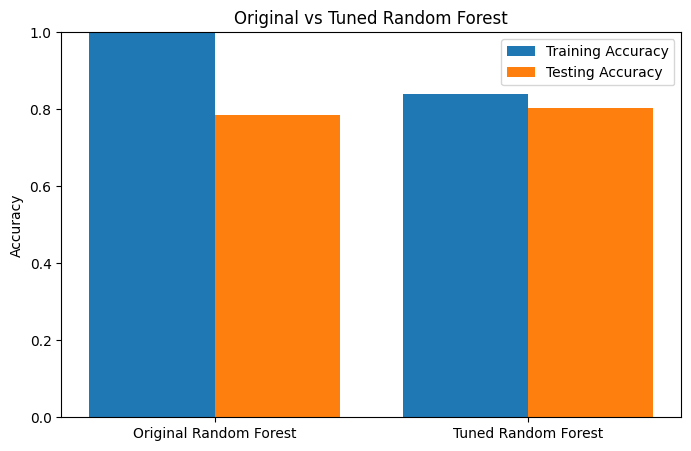

In [20]:
import matplotlib.pyplot as plt

models = ['Original Random Forest', 'Tuned Random Forest']
train_acc = [train_accuracy, train_accuracy_tuned]
test_acc = [test_accuracy, test_accuracy_tuned]

x = range(len(models))

plt.figure(figsize=(8, 5))

plt.bar([i - 0.2 for i in x], train_acc, width=0.4, label='Training Accuracy')
plt.bar([i + 0.2 for i in x], test_acc, width=0.4, label='Testing Accuracy')

plt.xticks(list(x), models)
plt.ylabel('Accuracy')
plt.title('Original vs Tuned Random Forest')
plt.ylim(0, 1)

plt.legend()
plt.show()

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
tenure                            0.204982
TotalCharges                      0.143764
MonthlyCharges                    0.109181
InternetService_Fiber optic       0.083110
PaymentMethod_Electronic check    0.066456
Contract_Two year                 0.063149
OnlineSecurity_Yes                0.040416
Contract_One year                 0.031873
TechSupport_Yes                   0.024786
PaperlessBilling_Yes              0.019059
dtype: float64


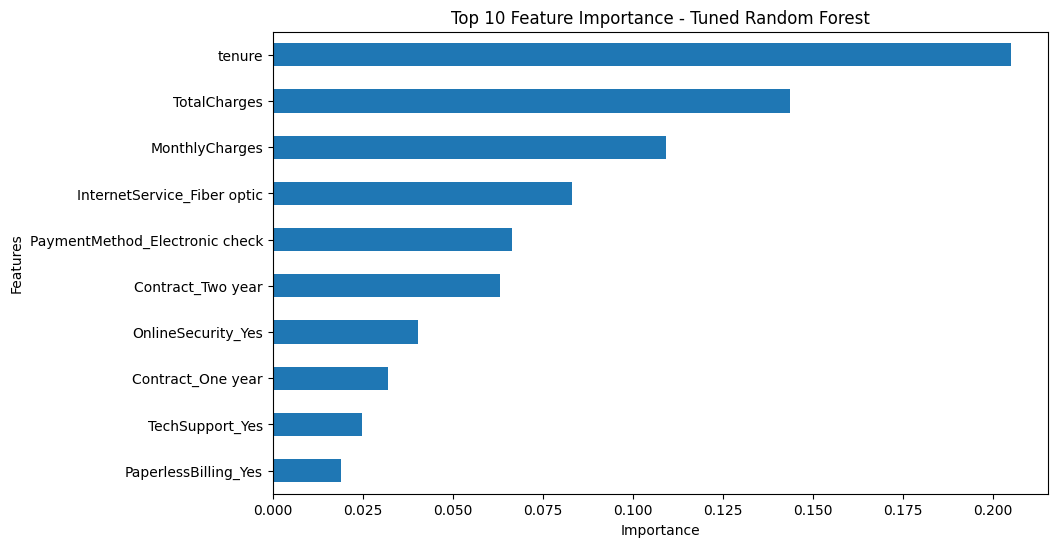

In [22]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind='barh')

plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance - Tuned Random Forest')
plt.show()

In [23]:
from sklearn.metrics import roc_auc_score

y_test_prob = rf_model_tuned.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_test_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.8441253971944509
